In [1]:
# Imports
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Para reprodutibilidade
np.random.seed(42)  

# Gera os dados
dados = np.random.randn(1000, 8)
df_dsa = pd.DataFrame(dados, columns = [f'Atributo_{i}' for i in range(1, 9)])

In [3]:
df_dsa.shape

(1000, 8)

# Padronização

In [5]:
scaller = StandardScaler()

In [6]:
dados_padronizados = scaller.fit_transform(df_dsa)

In [7]:
dados_padronizados

array([[ 0.50005258, -0.1079961 ,  0.69137884, ..., -0.2174599 ,
         1.54266063,  0.72124761],
       [-0.46570918,  0.57203085, -0.43181987, ..., -1.87318757,
        -1.65304186, -0.57797922],
       [-1.00882591,  0.34398554, -0.88126503, ..., -0.20921584,
         0.08058337, -1.42066048],
       ...,
       [-0.98387173,  0.75229737,  0.12308532, ..., -0.48368659,
        -0.05519563,  1.81736367],
       [ 0.24162393, -0.8096809 ,  0.25967332, ...,  0.5858837 ,
         1.18481977, -0.05231653],
       [ 1.6417944 ,  0.93706544, -0.67849748, ..., -0.81006669,
         1.61394232,  2.00153949]], shape=(1000, 8))

# Aplicando PCA

In [9]:
pca = PCA()

In [10]:
dados = pca.fit_transform(dados_padronizados)

In [11]:
# Matriz de Covariancia

print("Variância explicada por cada componente:", pca.explained_variance_ratio_)

Variância explicada por cada componente: [0.1409125  0.13238103 0.1307604  0.12946748 0.12256327 0.12096314
 0.11395785 0.10899434]


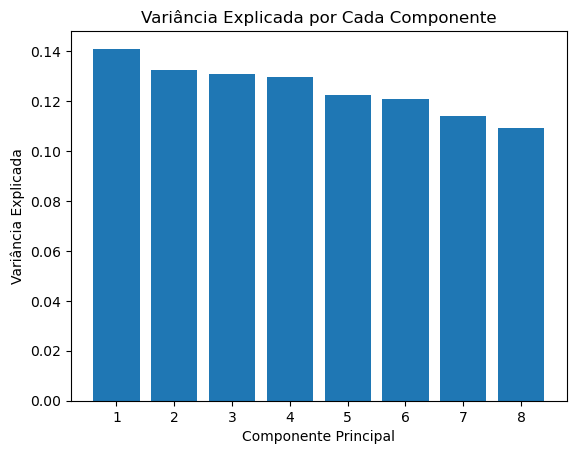

In [12]:
# visualizando a variancia explicada

# Variância explicada por componente
explained_var = pca.explained_variance_ratio_
componentes = range(1, len(explained_var) + 1)

# Plot
plt.bar(componentes, explained_var)

# Ajustar os ticks no eixo x
plt.xticks(componentes)

plt.xlabel('Componente Principal')
plt.ylabel('Variância Explicada')
plt.title('Variância Explicada por Cada Componente')
plt.show()

In [13]:
# Extraindo os componentes principais
componentes = pd.DataFrame(pca.components_, 
                           columns = df_dsa.columns, 
                           index = [f'PC-{i}' for i in range(1, 9)])

In [14]:
componentes

,Atributo_1,Atributo_2,Atributo_3,Atributo_4,Atributo_5,Atributo_6,Atributo_7,Atributo_8
PC-1,-0.196388,0.468139,-0.405046,-0.417747,0.436951,-0.448249,0.010965,0.108297
PC-2,0.275254,-0.406774,0.350551,-0.470875,0.485621,0.042320,-0.420036,0.010603
PC-3,0.389133,-0.176295,-0.305869,-0.250275,0.137979,0.371768,0.654928,0.274085
PC-4,-0.542503,-0.297805,-0.009931,0.296110,0.291527,0.101594,-0.043470,0.657285
PC-5,0.263291,0.017466,0.357604,-0.145364,-0.401602,-0.537062,0.112864,0.564716
PC-6,-0.446916,0.310198,0.585621,-0.388296,-0.030855,0.316280,0.325487,-0.058223
PC-7,0.265614,0.548444,-0.058386,0.008642,-0.092213,0.495751,-0.462134,0.396654
PC-8,0.316742,0.313520,0.380994,0.530533,0.546333,-0.120463,0.245726,-0.037217


In [15]:
df_dsa['target'] = np.random.randint(0, 2, df_dsa.shape[0])

In [16]:
scores = []

In [17]:
# Loop sobre o número de componentes do PCA de 1 a 8
for i in range(1, 9):
    
    # Cria um objeto PCA com i componentes
    pca = PCA(n_components = i)
    
    # Ajusta o PCA aos dados escalonados e transforma os dados
    pca_data = pca.fit_transform(dados_padronizados)
    
    # Cria um objeto de regressão logística
    lr = LogisticRegression()
    
    # Avalia a regressão logística usando validação cruzada e calcula a média das pontuações
    score = cross_val_score(lr, pca_data, df_dsa['target'], cv = 5).mean()
    
    # Adiciona a média das pontuações à lista de pontuações
    scores.append(score)

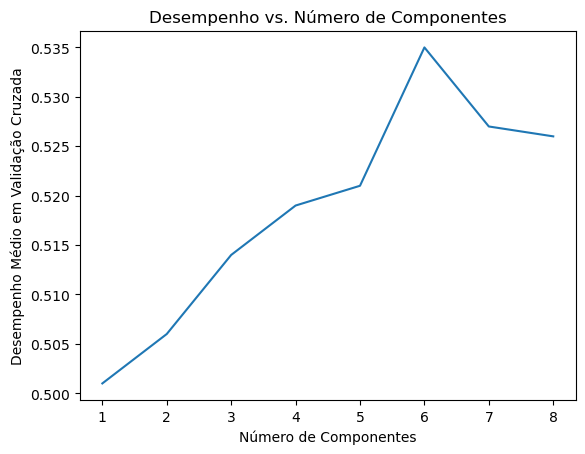

In [18]:
# Plot
plt.plot(range(1, 9), scores)
plt.xlabel('Número de Componentes')
plt.ylabel('Desempenho Médio em Validação Cruzada')
plt.title('Desempenho vs. Número de Componentes')
plt.show()

In [19]:
# Aplicando o LOOCV
dsa_loo = LeaveOneOut()
dsa_lr = LogisticRegression()
scores_loo = cross_val_score(dsa_lr, pca_data, df_dsa['target'], cv = dsa_loo)
print(f"LOOCV Score: {scores_loo.mean()}")

LOOCV Score: 0.523


In [20]:
# Considerando que 6 é o número ideal de componentes
pca_final = PCA(n_components = 6)
pca_data_final = pca_final.fit_transform(dados_padronizados)
modelo_dsa_lr_final = LogisticRegression()
modelo_dsa_lr_final.fit(pca_data_final, df_dsa['target'])

LogisticRegression()

In [21]:
# Simulando novos dados de sensores de uma máquina industrial
novos_dados_sensores = np.random.randn(1, 8)
novos_dados_sensores

array([[ 0.92528189,  0.16865137,  0.67635705, -0.03768712,  0.2338651 ,
         1.16499088,  0.62531833, -0.16927444]])

In [22]:
# Padroniza os dados de entrada
novos_dados_padronizados = scaller.transform(novos_dados_sensores)

In [23]:
# Aplica o PCA
pca_new_data = pca_final.transform(novos_dados_padronizados)

In [24]:
# Previsão com novos dados
previsao = modelo_dsa_lr_final.predict(pca_new_data)
print(previsao)

[1]
